# 01 — Orders Table: EDA, Target Engineering & Preprocessing
**Owner:** Member A

Covers: `olist_orders_dataset.csv` (+ optional light look at `olist_order_reviews_dataset.csv` for EDA only)

| Item | Detail |
|---|---|
| Project | IT3051 Fundamentals of Data Mining: Late Delivery Risk Prediction (Olist) |
| Task type | Binary classification: *"Will an order be delivered late?"* |
| Target | `is_late_delivery` (1 = Late, 0 = On time) |
| Input | `../data/raw/olist_orders_dataset.csv` (raw file is **read only**, never modified) |
| Output | `../data/processed/orders_clean.csv` (one row per order, handed to Member D for the final merge) |
| Out of scope here | customers/sellers/geo (B), items/products (C), payments + final merge + train/test split + modelling (D) |

**How this notebook is organised:** Part 1 is data understanding and EDA (Stage 3). Part 2 is target construction.
Part 3 is leakage analysis. Part 4 is preprocessing and feature engineering (Stage 4). Part 5 contains the final checks and the saved output.
Each section follows the same pattern: *what we check → code → result → interpretation → decision*.

## 0. Setup

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Consistent, readable plot style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titleweight"] = "bold"

# Two fixed colours used everywhere: On time = blue, Late = orange
COLOR_ON_TIME = "#2a78d6"
COLOR_LATE = "#eb6834"
COLOR_NEUTRAL = "#8a8a8a"

# Relative paths (the notebook is run from the notebooks/ folder)
RAW_PATH = "../data/raw/olist_orders_dataset.csv"
REVIEWS_PATH = "../data/raw/olist_order_reviews_dataset.csv"   # optional
OUT_PATH = "../data/processed/orders_clean.csv"

print("pandas", pd.__version__, "| numpy", np.__version__, "| seaborn", sns.__version__)
print("Raw orders file found:", os.path.exists(RAW_PATH))

pandas 3.0.2 | numpy 2.4.4 | seaborn 0.13.2
Raw orders file found: True


---
# PART 1: Data Understanding & EDA (Stage 3)

## 1. Load the raw data and first look
We load the CSV **without** any automatic date parsing first. That way we see the file exactly as it is stored,
and in Section 4 we can check whether every date value is actually parseable.

In [2]:
orders_raw = pd.read_csv(RAW_PATH)

print("Shape (rows, columns):", orders_raw.shape)
print("\nColumns:", orders_raw.columns.tolist())
orders_raw.head()

Shape (rows, columns): (99441, 8)

Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [3]:
# Data types as loaded: all 8 columns are read as text (object/str)
orders_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


**Interpretation:** The table has one row per order and 8 columns. All the columns in the actual file match the expected Olist schema.
All columns are read as text, which means the five date/time columns **must be converted** to datetime before we can do any date arithmetic.

### 1.1 Data dictionary and *when* each value becomes known
For a prediction project, the most important property of each column is **when it becomes known** in the life of an order.

| Column | Type | Meaning | Known at… |
|---|---|---|---|
| `order_id` | ID (text) | Unique order identifier | Order placement |
| `customer_id` | ID (text) | Customer key for this order (links to customers table, Member B) | Order placement |
| `order_status` | Categorical | Current status of the order (delivered, shipped, canceled, …) | Changes over time; the final value is known **only at the end** |
| `order_purchase_timestamp` | Datetime | When the customer placed the order | Order placement |
| `order_approved_at` | Datetime | When the payment was approved | After payment approval (minutes to days after purchase) |
| `order_delivered_carrier_date` | Datetime | When the seller handed the parcel to the carrier | After dispatch |
| `order_delivered_customer_date` | Datetime | When the customer received the order | After delivery (**this is the outcome**) |
| `order_estimated_delivery_date` | Date | Delivery date promised to the customer | Order placement (shown at checkout) |

The Olist dataset documentation (Kaggle) describes `order_estimated_delivery_date` as the estimated delivery date that was
*"informed to customer at the purchase moment"*. This is why it can be used for a prediction-time feature (Section 17).

### 1.2 Descriptive statistics (raw, before type conversion)

In [4]:
orders_raw.describe(include="all").T

,count,unique,top,freq
order_id,99441,99441,e481f51cbdc54678b7cc49136f2d6af7,1
customer_id,99441,99441,9ef432eb6251297304e76186b10a928d,1
order_status,99441,8,delivered,96478
order_purchase_timestamp,99441,98875,2018-03-31 15:08:21,3
order_approved_at,99281,90733,2018-02-27 04:31:10,9
order_delivered_carrier_date,97658,81018,2018-05-09 15:48:00,47
order_delivered_customer_date,96476,95664,2018-05-14 20:02:44,3
order_estimated_delivery_date,99441,459,2017-12-20 00:00:00,522


**Interpretation:** `order_id` and `customer_id` have as many unique values as there are rows, so each appears once.
`order_status` has only a handful of categories, and one category dominates (see Section 3).
The date columns have fewer non-null values than the number of rows, which means they contain missing values (Section 5).

## 2. Duplicates and key uniqueness
Member D will merge on `order_id`, so `order_id` **must** be unique. We check:
1. fully duplicated rows
2. duplicated `order_id`
3. duplicated `customer_id` (in Olist, a new `customer_id` is generated for every order. The real person is `customer_unique_id` in the customers table, which Member B owns.)

In [5]:
print("Fully duplicated rows      :", orders_raw.duplicated().sum())
print("Duplicated order_id        :", orders_raw["order_id"].duplicated().sum())
print("Duplicated customer_id     :", orders_raw["customer_id"].duplicated().sum())
print("order_id is unique         :", orders_raw["order_id"].is_unique)
print("Unique order_id / rows     :", orders_raw["order_id"].nunique(), "/", len(orders_raw))

Fully duplicated rows      : 0
Duplicated order_id        : 0
Duplicated customer_id     : 0
order_id is unique         : True
Unique order_id / rows     : 99441 / 99441


**Interpretation and decision:** There are no duplicate rows, no duplicate `order_id`, and no duplicate `customer_id`. The table is already at the
**one-row-per-order** grain that the final merge needs. **No de-duplication is required.** We still re-check uniqueness
on the final output (Section 20) because the filtering steps must not break it.

## 3. Order status distribution
The target can only be determined for orders that actually reached the customer. So before building the target, we must
understand which statuses exist.

In [6]:
status_counts = orders_raw["order_status"].value_counts()
status_pct = (orders_raw["order_status"].value_counts(normalize=True) * 100).round(3)
status_table = pd.DataFrame({"count": status_counts, "percent": status_pct})
status_table

,count,percent
order_status,,
delivered,96478,97.020
shipped,1107,1.113
canceled,625,0.629
unavailable,609,0.612
invoiced,314,0.316
processing,301,0.303
created,5,0.005
approved,2,0.002


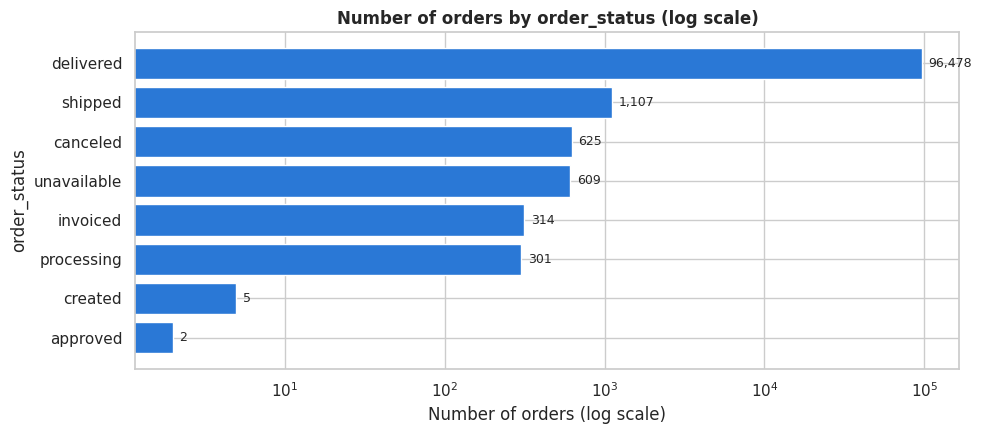

In [7]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.barh(status_counts.index[::-1], status_counts.values[::-1], color=COLOR_ON_TIME)
ax.set_xscale("log")
ax.set_title("Number of orders by order_status (log scale)")
ax.set_xlabel("Number of orders (log scale)")
ax.set_ylabel("order_status")
for i, v in enumerate(status_counts.values[::-1]):
    ax.text(v * 1.1, i, f"{v:,}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

**Interpretation:** `delivered` is by far the most common status (see the table for the exact share). All other statuses
(`shipped`, `canceled`, `unavailable`, `invoiced`, `processing`, `created`, `approved`) describe orders that either **have not
reached the customer yet** or **never will**. We cannot know whether those orders would have been late, so labelling them
0 ("on time") would be wrong. This leads to the target-population decision in Section 8.

A log scale is used because the delivered bar is so large that the other bars would otherwise be invisible.

## 4. Date parsing and validity
We convert the five date columns using an **explicit format** and `errors="coerce"`. Any value that cannot be parsed becomes
`NaT` (missing). If a column has **more** missing values after parsing than before, that column contains invalid, unparseable text.

In [8]:
DATE_COLS = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

orders = orders_raw.copy()          # work on a copy, never on the raw data
for col in DATE_COLS:
    orders[col] = pd.to_datetime(orders[col], format="%Y-%m-%d %H:%M:%S", errors="coerce")

parse_check = pd.DataFrame({
    "missing_before_parsing": orders_raw[DATE_COLS].isna().sum(),
    "missing_after_parsing": orders[DATE_COLS].isna().sum(),
})
parse_check["unparseable_values"] = parse_check["missing_after_parsing"] - parse_check["missing_before_parsing"]
parse_check

,missing_before_parsing,missing_after_parsing,unparseable_values
order_purchase_timestamp,0,0,0
order_approved_at,160,160,0
order_delivered_carrier_date,1783,1783,0
order_delivered_customer_date,2965,2965,0
order_estimated_delivery_date,0,0,0


In [9]:
# Range of each date column: are there impossible years?
date_ranges = pd.DataFrame({"min": orders[DATE_COLS].min(), "max": orders[DATE_COLS].max()})
date_ranges

,min,max
order_purchase_timestamp,2016-09-04 21:15:19,2018-10-17 17:30:18
order_approved_at,2016-09-15 12:16:38,2018-09-03 17:40:06
order_delivered_carrier_date,2016-10-08 10:34:01,2018-09-11 19:48:28
order_delivered_customer_date,2016-10-11 13:46:32,2018-10-17 13:22:46
order_estimated_delivery_date,2016-09-30 00:00:00,2018-11-12 00:00:00


In [10]:
# The estimated delivery date looks like a date without a time. Check: how many values have a non-midnight time?
est = orders["order_estimated_delivery_date"]
non_midnight = ((est.dt.hour != 0) | (est.dt.minute != 0) | (est.dt.second != 0)).sum()
print("Estimated delivery dates with a time other than 00:00:00:", non_midnight)

Estimated delivery dates with a time other than 00:00:00: 0


**Interpretation:**
- **No unparseable values.** Every non-empty value in every date column converts to a valid datetime. The only missing values
  are the ones that were already empty in the raw file.
- All dates fall within the known period of the dataset (2016–2018). There are no impossible years such as 1900 or 2099.
- `order_estimated_delivery_date` is stored as a **date only** (always 00:00:00). This matters for the target definition
  (Section 10.1).

**Decision:** Keep the parsed datetime columns in the working copy `orders`. The raw DataFrame and the raw CSV are left untouched.

## 5. Missing values: counts, percentages and patterns

In [11]:
missing = pd.DataFrame({
    "missing_count": orders.isna().sum(),
    "missing_percent": (orders.isna().mean() * 100).round(3),
})
missing

,missing_count,missing_percent
order_id,0,0.000
customer_id,0,0.000
order_status,0,0.000
order_purchase_timestamp,0,0.000
order_approved_at,160,0.161
order_delivered_carrier_date,1783,1.793
order_delivered_customer_date,2965,2.982
order_estimated_delivery_date,0,0.000


Missing values here are unlikely to be random. A delivery date should be empty if the order was never delivered.
To test this, we look at the **missing percentage of each date column within each `order_status`**.

In [12]:
missing_by_status = (
    orders.groupby("order_status")[DATE_COLS]
    .apply(lambda g: g.isna().mean() * 100)
    .round(1)
)
missing_by_status["n_orders"] = orders["order_status"].value_counts()
missing_by_status = missing_by_status.sort_values("n_orders", ascending=False)
missing_by_status

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,n_orders
order_status,,,,,,
delivered,0.0,0.0,0.0,0.0,0.0,96478
shipped,0.0,0.0,0.0,100.0,0.0,1107
canceled,0.0,22.6,88.0,99.0,0.0,625
unavailable,0.0,0.0,100.0,100.0,0.0,609
invoiced,0.0,0.0,100.0,100.0,0.0,314
processing,0.0,0.0,100.0,100.0,0.0,301
created,0.0,100.0,100.0,100.0,0.0,5
approved,0.0,0.0,100.0,100.0,0.0,2


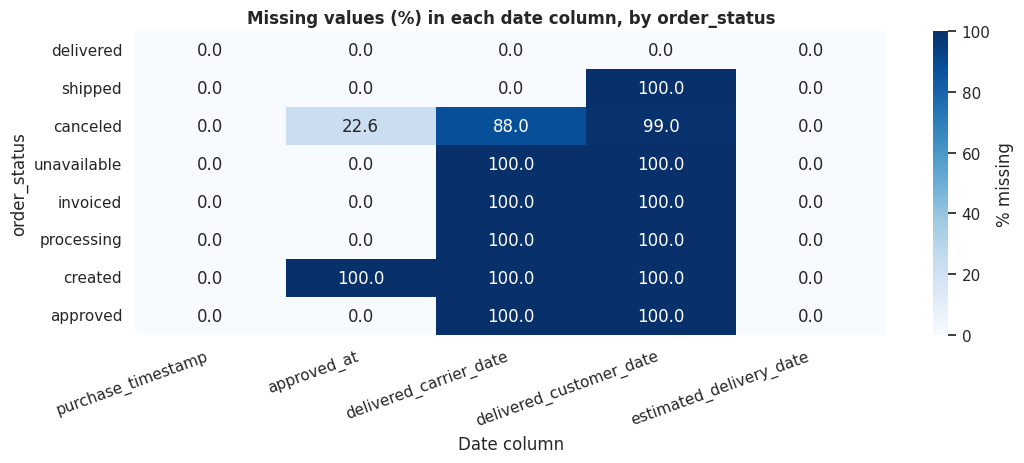

In [13]:
fig, ax = plt.subplots(figsize=(11, 4.8))
sns.heatmap(
    missing_by_status[DATE_COLS],
    annot=True, fmt=".1f", cmap="Blues", vmin=0, vmax=100,
    cbar_kws={"label": "% missing"}, ax=ax,
)
ax.set_title("Missing values (%) in each date column, by order_status")
ax.set_xlabel("Date column")
ax.set_ylabel("order_status")
ax.set_xticklabels([c.replace("order_", "") for c in DATE_COLS], rotation=20, ha="right")
plt.tight_layout()
plt.show()

In [14]:
# Exact counts for the cases that matter for the target
delivered = orders["order_status"] == "delivered"
print("Delivered orders missing order_delivered_customer_date :", (delivered & orders["order_delivered_customer_date"].isna()).sum())
print("Delivered orders missing order_approved_at             :", (delivered & orders["order_approved_at"].isna()).sum())
print("Delivered orders missing order_delivered_carrier_date  :", (delivered & orders["order_delivered_carrier_date"].isna()).sum())
print("NON-delivered orders that DO have a customer delivery date:",
      (~delivered & orders["order_delivered_customer_date"].notna()).sum())
print(orders.loc[~delivered & orders["order_delivered_customer_date"].notna(), "order_status"].value_counts())

Delivered orders missing order_delivered_customer_date : 8
Delivered orders missing order_approved_at             : 14
Delivered orders missing order_delivered_carrier_date  : 2
NON-delivered orders that DO have a customer delivery date: 6
order_status
canceled    6
Name: count, dtype: int64


**Interpretation:** Missingness is **structural**. It follows the order's progress through the pipeline:
- `order_purchase_timestamp` and `order_estimated_delivery_date` are **never missing**. Both exist from the moment the order is placed.
- `order_delivered_customer_date` is missing for almost all non-delivered orders. This is expected, because they were never delivered.
- For `delivered` orders, missing values are rare (a small number of rows, printed above). These are **data-entry
  inconsistencies**: the status says delivered, but a timestamp is absent.
- A few `canceled` orders have a customer delivery date. This is contradictory, since an order cannot be both delivered and cancelled.

**Decision:** No imputation of delivery dates. Imputing a delivery date would mean inventing the outcome we are trying to
predict. These patterns are handled by selecting the correct target population instead (Section 8). Missing
`order_approved_at` is discussed with the approval feature in Sections 14 and 19.

## 6. Chronological consistency (invalid / unusual records)
In a correct order timeline, events happen in this order: purchase → approval → carrier pick-up → customer delivery.
We count rows where this order is violated. We also check that the promised date is not before the purchase.

In [15]:
p  = orders["order_purchase_timestamp"]
ap = orders["order_approved_at"]
ca = orders["order_delivered_carrier_date"]
de = orders["order_delivered_customer_date"]
es = orders["order_estimated_delivery_date"]

consistency = pd.Series({
    "approved before purchase":            (ap < p).sum(),
    "carrier pick-up before purchase":     (ca < p).sum(),
    "carrier pick-up before approval":     (ca < ap).sum(),
    "customer delivery before purchase":   (de < p).sum(),
    "customer delivery before carrier":    (de < ca).sum(),
    "estimated delivery before purchase":  (es < p).sum(),
}, name="number_of_orders")
consistency.to_frame()

,number_of_orders
approved before purchase,0
carrier pick-up before purchase,166
carrier pick-up before approval,1359
customer delivery before purchase,0
customer delivery before carrier,23
estimated delivery before purchase,0


**Interpretation:**
- The columns we need for the **target** (`order_delivered_customer_date`, `order_estimated_delivery_date`) and the
  **prediction-time features** (`order_purchase_timestamp`, `order_estimated_delivery_date`) are chronologically valid.
  No delivery happens before purchase, and no promised date is before purchase.
- The inconsistencies are found only in the **carrier pick-up date** (it sometimes appears before purchase/approval, or after the
  customer delivery). These look like recording or time-zone problems in the logistics system.

**Decision:** Do **not** drop these rows. `order_delivered_carrier_date` is a post-dispatch column that is **excluded from the
model** anyway (Section 16). Its errors therefore cannot distort the features or the target. Dropping the rows would
throw away valid target labels for no benefit. The issue is documented as a data-quality observation.

## 7. Time coverage of the dataset
Before analysing lateness over time, we need to know how many orders exist in each month and which months are
**complete**. At the end of a data extract, recent orders often have not been delivered yet.

In [16]:
orders["purchase_month_period"] = orders["order_purchase_timestamp"].dt.to_period("M")

monthly = orders.groupby("purchase_month_period").agg(
    total_orders=("order_id", "count"),
    delivered_orders=("order_status", lambda s: (s == "delivered").sum()),
)
monthly["delivered_share_%"] = (monthly["delivered_orders"] / monthly["total_orders"] * 100).round(1)
monthly

,total_orders,delivered_orders,delivered_share_%
purchase_month_period,,,
2016-09,4,1,25.0
2016-10,324,265,81.8
2016-12,1,1,100.0
2017-01,800,750,93.8
2017-02,1780,1653,92.9
2017-03,2682,2546,94.9
2017-04,2404,2303,95.8
2017-05,3700,3546,95.8
2017-06,3245,3135,96.6


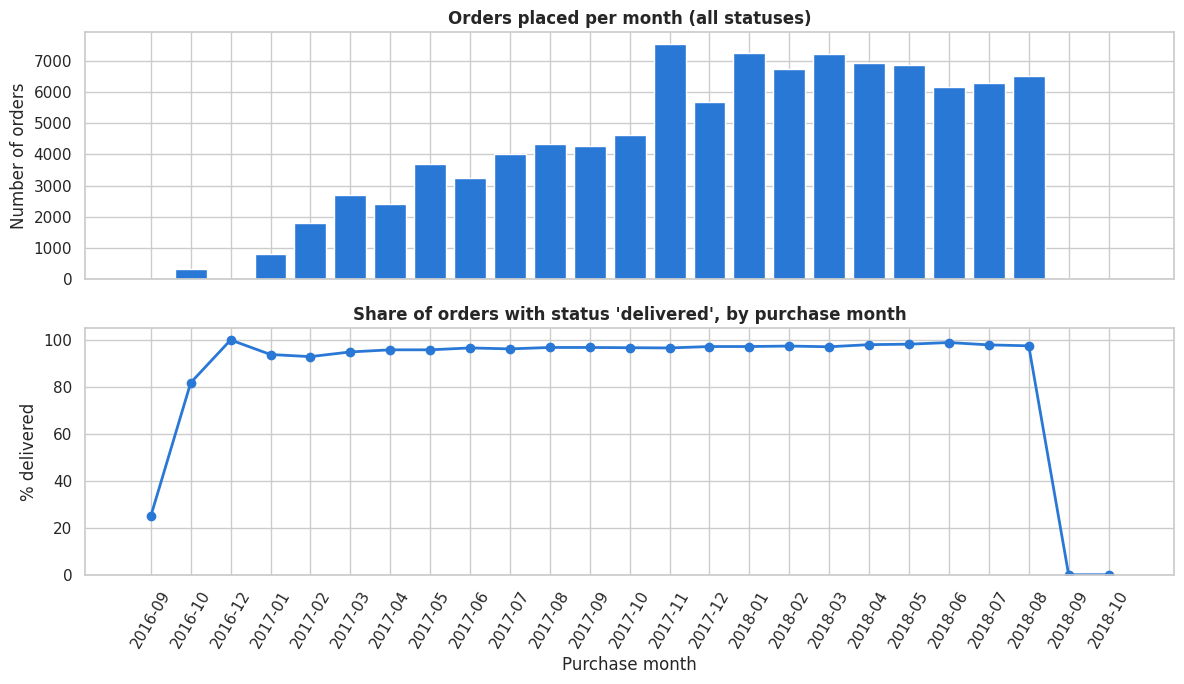

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
x = monthly.index.astype(str)

axes[0].bar(x, monthly["total_orders"], color=COLOR_ON_TIME)
axes[0].set_title("Orders placed per month (all statuses)")
axes[0].set_ylabel("Number of orders")

axes[1].plot(x, monthly["delivered_share_%"], marker="o", color=COLOR_ON_TIME, linewidth=2)
axes[1].set_title("Share of orders with status 'delivered', by purchase month")
axes[1].set_ylabel("% delivered")
axes[1].set_xlabel("Purchase month")
axes[1].set_ylim(0, 105)

plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

**Interpretation:**
- **2016 is very sparse**, with only a few hundred orders and some months missing entirely. The business mainly starts in 2017.
- Volume grows through 2017 and is fairly stable in 2018.
- The **last months (after August 2018) contain almost no orders and no delivered ones**. This is the end of the data extract.
- In the older months the delivered share is also lower. This fits the extract being a snapshot: orders that never completed stay undelivered.

**Consequences for modelling:**
1. Because the target exists only for delivered orders, the final months contribute **no labelled rows**. They drop out
   naturally when we filter to delivered orders.
2. Orders placed just before the cut-off that were slow to arrive may not have been delivered by the extract date.
   The labelled data can therefore slightly **under-represent late deliveries at the very end of the period** (a censoring effect).
   Member D should keep this in mind when choosing the final test window of the chronological split.

---
# PART 2: Target Construction

## 8. Choosing the target population
`is_late_delivery` compares the **actual** delivery date with the **promised** date. It can only be computed when the
order was actually delivered. We therefore keep an order only if **both** conditions hold:
1. `order_status == "delivered"`, meaning the order completed its life-cycle normally, **and**
2. `order_delivered_customer_date` is not missing, meaning we know when it arrived.

The following orders are excluded (not labelled):
- **shipped / invoiced / processing / approved / created**: still in progress, so the outcome is unknown.
- **canceled / unavailable**: never delivered, so the question "was it late?" does not apply.
- **canceled but with a delivery date**: contradictory status, unreliable record.
- **delivered but missing the delivery date**: the outcome cannot be computed.

Labelling any of these as 0 ("on time") would be a **labelling error**. Most of them were never delivered at all.

In [18]:
is_delivered_status = orders["order_status"] == "delivered"
has_delivery_date = orders["order_delivered_customer_date"].notna()

population_breakdown = pd.Series({
    "all orders":                                   len(orders),
    "excluded: status not delivered":               (~is_delivered_status).sum(),
    "   of which: canceled but with delivery date": (~is_delivered_status & has_delivery_date).sum(),
    "excluded: delivered but no delivery date":     (is_delivered_status & ~has_delivery_date).sum(),
    "TARGET POPULATION (kept)":                     (is_delivered_status & has_delivery_date).sum(),
}, name="orders")
population_breakdown.to_frame()

,orders
all orders,99441
excluded: status not delivered,2963
of which: canceled but with delivery date,6
excluded: delivered but no delivery date,8
TARGET POPULATION (kept),96470


In [19]:
target_df = orders[is_delivered_status & has_delivery_date].copy()

print("Rows in target population:", len(target_df))
print(f"Share of all orders kept : {len(target_df) / len(orders) * 100:.2f}%")
print("Rows removed             :", len(orders) - len(target_df))

Rows in target population: 96470
Share of all orders kept : 97.01%
Rows removed             : 2971


**Interpretation:** Only a small share of all orders is removed, and every removed order is one whose delivery outcome
is genuinely unknown or unreliable. The remaining population is large enough for modelling.

**Note for the deployed system:** at prediction time the system will score **new** orders, which have no status yet.
The model is trained on delivered orders because only they have a known answer. Cancelled orders are a different
business question and are **not** treated as "late".

## 9. Build the target `is_late_delivery`
Definition (agreed in the README):

```
is_late_delivery = 1   if order_delivered_customer_date > order_estimated_delivery_date
                 = 0   otherwise
```

In [20]:
target_df["is_late_delivery"] = (
    target_df["order_delivered_customer_date"] > target_df["order_estimated_delivery_date"]
).astype(int)

print("Missing target values:", target_df["is_late_delivery"].isna().sum())
print("Unique target values :", sorted(target_df["is_late_delivery"].unique()))

Missing target values: 0
Unique target values : [np.int64(0), np.int64(1)]


## 10. Target distribution and class imbalance

In [21]:
target_counts = target_df["is_late_delivery"].value_counts().sort_index()
target_pct = (target_df["is_late_delivery"].value_counts(normalize=True).sort_index() * 100).round(2)
target_table = pd.DataFrame({"label": ["On time (0)", "Late (1)"], "count": target_counts.values, "percent": target_pct.values})
print(target_table.to_string(index=False))
print(f"\nImbalance ratio (on time : late) = {target_counts[0] / target_counts[1]:.1f} : 1")

      label  count  percent
On time (0)  88644    91.89
   Late (1)   7826     8.11

Imbalance ratio (on time : late) = 11.3 : 1


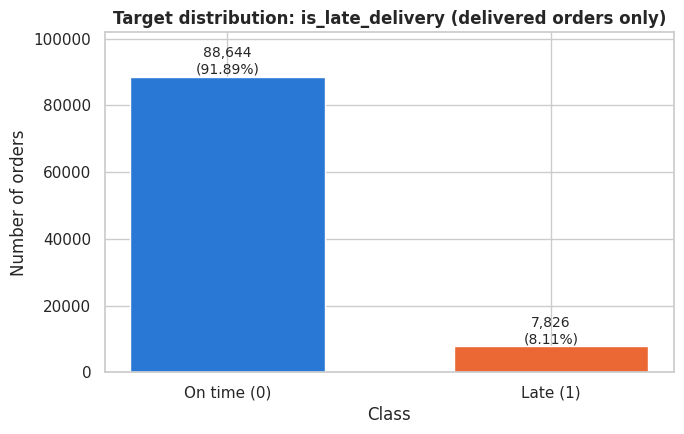

In [22]:
fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(["On time (0)", "Late (1)"], target_counts.values, color=[COLOR_ON_TIME, COLOR_LATE], width=0.6)
for bar, c, pc in zip(bars, target_counts.values, target_pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2, c, f"{c:,}\n({pc}%)", ha="center", va="bottom", fontsize=10)
ax.set_title("Target distribution: is_late_delivery (delivered orders only)")
ax.set_xlabel("Class")
ax.set_ylabel("Number of orders")
ax.set_ylim(0, target_counts.max() * 1.15)
plt.tight_layout()
plt.show()

**Interpretation:** The target is **strongly imbalanced**. Late deliveries are the minority class (see the exact
percentage and ratio printed above).

**Consequences for modelling (for Member D / Stage 6):**
- **Accuracy is misleading.** A model that always predicts "on time" would already reach an accuracy equal to the on-time share
  shown above, while catching zero late orders. Use **recall, precision, F1 and PR-AUC for the Late class**, plus ROC-AUC.
- Consider `class_weight="balanced"`, threshold tuning, or resampling (for example SMOTE from `imbalanced-learn`, which is
  already in `requirements.txt`). Any resampling must be applied **to the training set only, after the split**.
- **No resampling is done in this notebook.** Resampling before the train/test split would leak synthetic copies of
  test information into training.

### 10.1 Boundary issue: deliveries on the promised day
`order_estimated_delivery_date` has no time (it is always 00:00:00), but `order_delivered_customer_date` does.
With the strict `>` rule, an order delivered at, for example, 15:00 **on the promised day** is counted as **late**.
We quantify how many labels depend on this.

In [23]:
delivered_day = target_df["order_delivered_customer_date"].dt.normalize()   # delivery date without time
same_day_late = (target_df["is_late_delivery"] == 1) & (delivered_day == target_df["order_estimated_delivery_date"])

n_late = target_df["is_late_delivery"].sum()
print("Late orders (strict timestamp rule)             :", n_late)
print("…of which delivered ON the promised calendar day:", same_day_late.sum(),
      f"({same_day_late.sum() / n_late * 100:.1f}% of late orders)")

late_rate_strict = target_df["is_late_delivery"].mean() * 100
late_rate_day_rule = ((delivered_day > target_df["order_estimated_delivery_date"]).mean()) * 100
print(f"\nLate rate with strict rule (current definition) : {late_rate_strict:.2f}%")
print(f"Late rate if 'late' meant 'after the promised DAY': {late_rate_day_rule:.2f}%")

Late orders (strict timestamp rule)             : 7826
…of which delivered ON the promised calendar day: 1292 (16.5% of late orders)

Late rate with strict rule (current definition) : 8.11%
Late rate if 'late' meant 'after the promised DAY': 6.77%


**Interpretation:** A noticeable part of the late class consists of orders that arrived **on** the promised calendar day
(see the printed share). From a customer's point of view, *"arrives by 10 September"* usually means *"any time on 10 September"*.
These orders are arguably **on time**.

**Decision (unchanged, but flagged):** This notebook uses the **official project definition** (strict `>`), because it is the
definition written in the README and in the task brief. The alternative *day-level* rule is **not** added as a second column,
because a second target-like column in the output could be used as a feature by mistake (leakage). **This is listed
as a decision for the team to confirm** (see the Summary). If the team switches, only one line in Section 9 changes:
`target_df["order_delivered_customer_date"].dt.normalize() > target_df["order_estimated_delivery_date"]`.

## 11. Delivery timing (EDA only: these columns are *never* model features)
To understand the problem, we compute three durations. They use the **actual** delivery date, so they are
**outcome information**. They are prefixed `eda_` and are **dropped before saving**.

| EDA column | Formula | Why it is leakage |
|---|---|---|
| `eda_actual_delivery_days` | delivered − purchase | Uses the delivery date, which is known only after the outcome |
| `eda_delay_days` | delivered − estimated | `> 0` is exactly the target definition |
| `eda_estimated_delivery_days` | estimated − purchase | *Not* leakage. Becomes the feature `estimated_delivery_days` in Section 17 |

In [24]:
SECONDS_PER_DAY = 24 * 60 * 60

target_df["eda_actual_delivery_days"] = (
    target_df["order_delivered_customer_date"] - target_df["order_purchase_timestamp"]
).dt.total_seconds() / SECONDS_PER_DAY

target_df["eda_estimated_delivery_days"] = (
    target_df["order_estimated_delivery_date"] - target_df["order_purchase_timestamp"]
).dt.total_seconds() / SECONDS_PER_DAY

target_df["eda_delay_days"] = (
    target_df["order_delivered_customer_date"] - target_df["order_estimated_delivery_date"]
).dt.total_seconds() / SECONDS_PER_DAY

timing_cols = ["eda_estimated_delivery_days", "eda_actual_delivery_days", "eda_delay_days"]
target_df[timing_cols].describe().round(2)

,eda_estimated_delivery_days,eda_actual_delivery_days,eda_delay_days
count,96470.00,96470.00,96470.00
mean,23.74,12.56,-11.18
std,8.76,9.55,10.18
min,2.01,0.53,-146.02
25%,18.33,6.77,-16.24
50%,23.23,10.22,-11.95
75%,28.41,15.72,-6.39
max,155.14,209.63,188.98


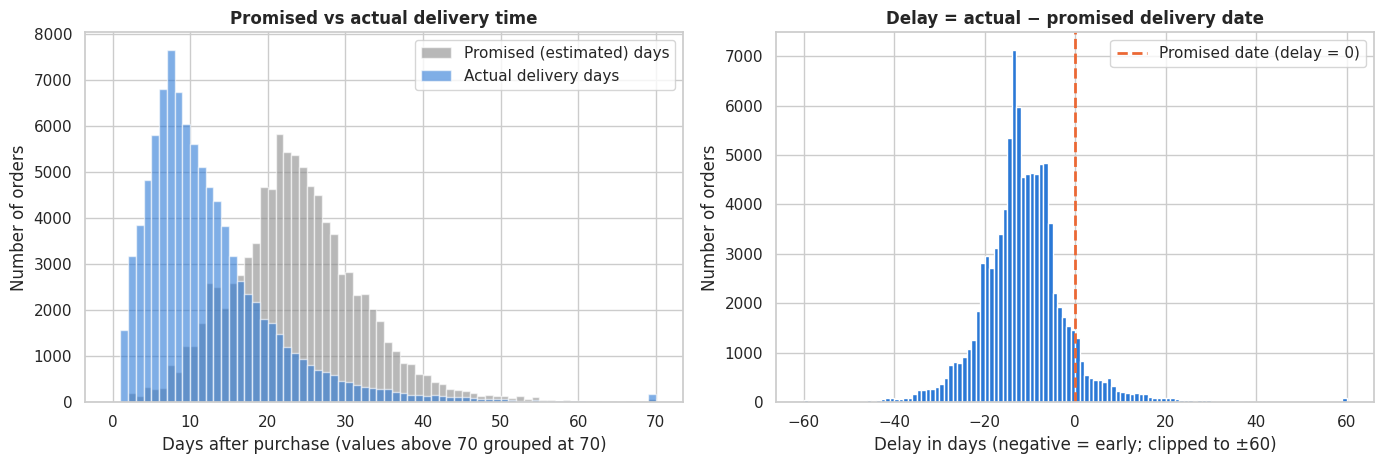

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

bins = np.arange(0, 71, 1)
axes[0].hist(target_df["eda_estimated_delivery_days"].clip(upper=70), bins=bins, alpha=0.6,
             color=COLOR_NEUTRAL, label="Promised (estimated) days")
axes[0].hist(target_df["eda_actual_delivery_days"].clip(upper=70), bins=bins, alpha=0.6,
             color=COLOR_ON_TIME, label="Actual delivery days")
axes[0].set_title("Promised vs actual delivery time")
axes[0].set_xlabel("Days after purchase (values above 70 grouped at 70)")
axes[0].set_ylabel("Number of orders")
axes[0].legend()

axes[1].hist(target_df["eda_delay_days"].clip(-60, 60), bins=np.arange(-60, 61, 1), color=COLOR_ON_TIME)
axes[1].axvline(0, color=COLOR_LATE, linestyle="--", linewidth=2, label="Promised date (delay = 0)")
axes[1].set_title("Delay = actual − promised delivery date")
axes[1].set_xlabel("Delay in days (negative = early; clipped to ±60)")
axes[1].set_ylabel("Number of orders")
axes[1].legend()

plt.tight_layout()
plt.show()

In [26]:
print(f"Median promised delivery time : {target_df['eda_estimated_delivery_days'].median():.1f} days")
print(f"Median actual delivery time   : {target_df['eda_actual_delivery_days'].median():.1f} days")
print(f"Median delay                  : {target_df['eda_delay_days'].median():.1f} days (negative = early)")
late_delays = target_df.loc[target_df['is_late_delivery'] == 1, 'eda_delay_days']
print(f"Among LATE orders, median delay: {late_delays.median():.1f} days; 90th percentile: {late_delays.quantile(0.9):.1f} days")

Median promised delivery time : 23.2 days
Median actual delivery time   : 10.2 days
Median delay                  : -11.9 days (negative = early)
Among LATE orders, median delay: 5.8 days; 90th percentile: 21.5 days


**Interpretation:**
- Olist's promises are **conservative**. The typical order arrives well **before** the promised date (the median delay is negative),
  and the actual-time distribution sits clearly to the left of the promised-time distribution.
- The delay distribution has a **long right tail**. When an order *is* late, it is usually a few days late, but some are
  weeks late.
- This means lateness is not about "slow delivery" in general. It is about orders whose delivery time **exceeds an
  already generous buffer**. Features that describe how large the buffer is (the promised time) are therefore
  directly relevant (Section 12).

## 12. Promised delivery time vs lateness
`estimated_delivery_days` is known at checkout, so it is a candidate feature. Does it relate to the target?

In [27]:
target_df["est_days_bin"] = pd.qcut(target_df["eda_estimated_delivery_days"], q=5)
late_by_est = (
    target_df.groupby("est_days_bin", observed=True)["is_late_delivery"]
    .agg(orders="count", late_rate="mean")
)
late_by_est["late_rate_%"] = (late_by_est["late_rate"] * 100).round(2)
late_by_est[["orders", "late_rate_%"]]

,orders,late_rate_%
est_days_bin,,
"(2.007, 16.861]",19294,8.56
"(16.861, 21.388]",19294,9.66
"(21.388, 25.138]",19294,8.82
"(25.138, 30.155]",19294,8.13
"(30.155, 155.135]",19294,5.41


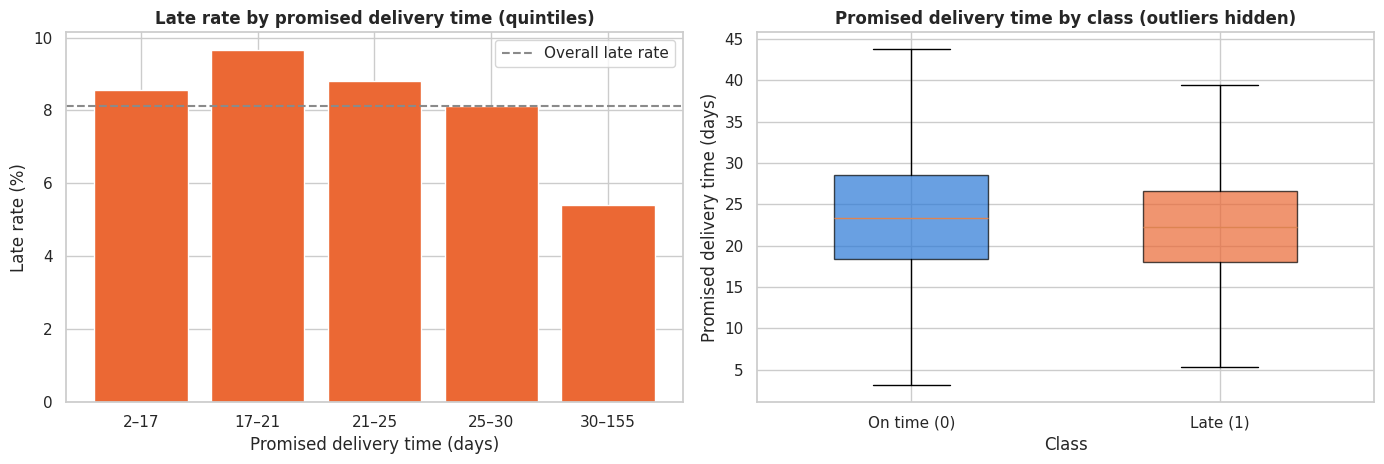

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

labels = [f"{iv.left:.0f}–{iv.right:.0f}" for iv in late_by_est.index]
axes[0].bar(labels, late_by_est["late_rate_%"], color=COLOR_LATE)
axes[0].axhline(target_df["is_late_delivery"].mean() * 100, color=COLOR_NEUTRAL, linestyle="--", label="Overall late rate")
axes[0].set_title("Late rate by promised delivery time (quintiles)")
axes[0].set_xlabel("Promised delivery time (days)")
axes[0].set_ylabel("Late rate (%)")
axes[0].legend()

box_data = [target_df.loc[target_df["is_late_delivery"] == k, "eda_estimated_delivery_days"] for k in (0, 1)]
bp = axes[1].boxplot(box_data, showfliers=False, patch_artist=True, widths=0.5)
for patch, colr in zip(bp["boxes"], [COLOR_ON_TIME, COLOR_LATE]):
    patch.set_facecolor(colr)
    patch.set_alpha(0.7)
axes[1].set_xticks([1, 2])
axes[1].set_xticklabels(["On time (0)", "Late (1)"])
axes[1].set_title("Promised delivery time by class (outliers hidden)")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Promised delivery time (days)")

plt.tight_layout()
plt.show()

**Interpretation:** Orders with the **longest** promised delivery times (top quintile) have a clearly **lower** late
rate than the other groups. A longer promise gives more buffer. The relationship is **not linear**: the lower
quintiles are similar to each other. This suggests the feature is useful, and that non-linear models (trees / boosting)
may use it better than a purely linear model. On its own, however, it does not separate the classes strongly. The
class boxes overlap a lot, so other domains (seller, customer location, product; Members B and C) will be needed.

## 13. Temporal patterns in lateness
Does the late rate depend on *when* the order was placed? We look at year, calendar month, day of week and hour,
and at the full month-by-month timeline.

In [29]:
ts = target_df["order_purchase_timestamp"]
target_df["eda_year"] = ts.dt.year
target_df["eda_month"] = ts.dt.month
target_df["eda_dayofweek"] = ts.dt.dayofweek      # 0 = Monday … 6 = Sunday
target_df["eda_hour"] = ts.dt.hour

late_by_year = target_df.groupby("eda_year")["is_late_delivery"].agg(orders="count", late_rate="mean")
late_by_year["late_rate_%"] = (late_by_year["late_rate"] * 100).round(2)
late_by_year[["orders", "late_rate_%"]]

,orders,late_rate_%
eda_year,,
2016,267,1.50
2017,43426,6.63
2018,52777,9.37


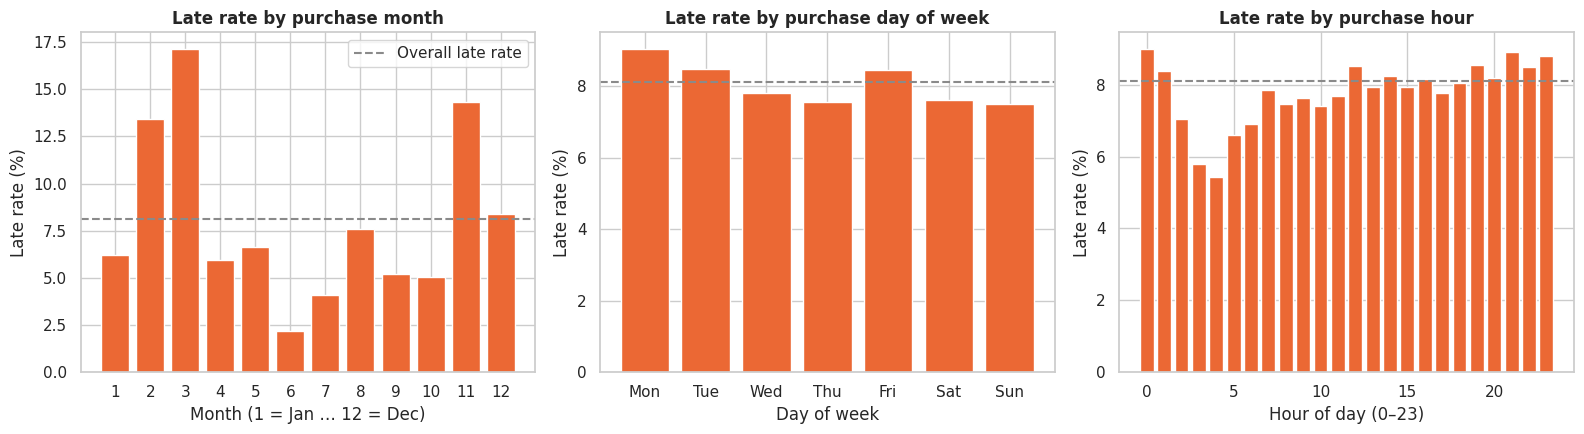

In [30]:
overall_rate = target_df["is_late_delivery"].mean() * 100
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

m = target_df.groupby("eda_month")["is_late_delivery"].mean() * 100
axes[0].bar(m.index, m.values, color=COLOR_LATE)
axes[0].set_title("Late rate by purchase month")
axes[0].set_xlabel("Month (1 = Jan … 12 = Dec)")
axes[0].set_xticks(range(1, 13))

d = target_df.groupby("eda_dayofweek")["is_late_delivery"].mean() * 100
axes[1].bar(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"], d.values, color=COLOR_LATE)
axes[1].set_title("Late rate by purchase day of week")
axes[1].set_xlabel("Day of week")

h = target_df.groupby("eda_hour")["is_late_delivery"].mean() * 100
axes[2].bar(h.index, h.values, color=COLOR_LATE)
axes[2].set_title("Late rate by purchase hour")
axes[2].set_xlabel("Hour of day (0–23)")

for ax in axes:
    ax.axhline(overall_rate, color=COLOR_NEUTRAL, linestyle="--", linewidth=1.5, label="Overall late rate")
    ax.set_ylabel("Late rate (%)")
axes[0].legend()
plt.tight_layout()
plt.show()

In [31]:
# Orders per day of week and hour (to know how much data supports each bar)
print("Orders by day of week:\n", target_df["eda_dayofweek"].value_counts().sort_index().to_string())
print("\nFewest orders in any hour:", target_df["eda_hour"].value_counts().min(),
      "| most:", target_df["eda_hour"].value_counts().max())

Orders by day of week:
 eda_dayofweek
0    15701
1    15502
2    15074
3    14322
4    13684
5    10555
6    11632

Fewest orders in any hour: 182 | most: 6475


Months not plotted (fewer than 100 delivered orders): ['2016-09', '2016-12']


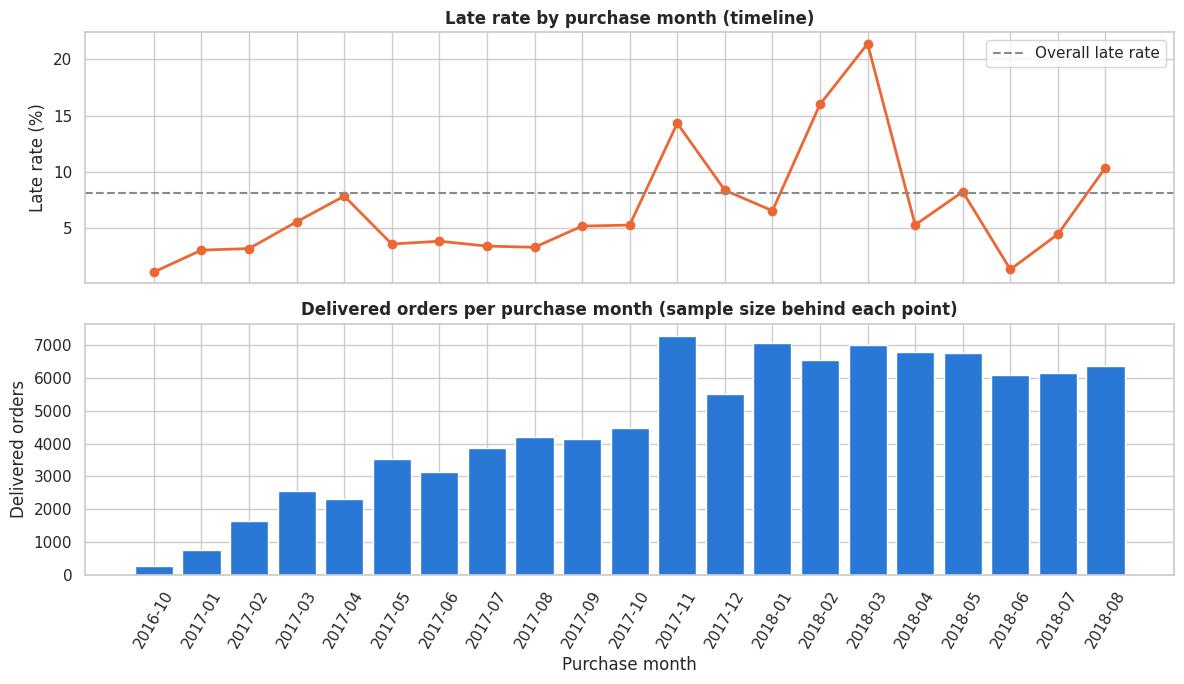

order_purchase_timestamp,2016-09,2016-10,2016-12,2017-01,2017-02,2017-03,2017-04,2017-05,2017-06,2017-07,...,2017-11,2017-12,2018-01,2018-02,2018-03,2018-04,2018-05,2018-06,2018-07,2018-08
orders,1.0,265.00,1.0,750.00,1653.00,2546.00,2303.00,3545.00,3135.00,3872.00,...,7288.00,5513.00,7069.00,6555.00,7003.00,6798.00,6749.00,6096.00,6156.00,6351.00
late_rate_%,100.0,1.13,0.0,3.07,3.21,5.58,7.86,3.61,3.86,3.43,...,14.31,8.38,6.56,15.99,21.36,5.31,8.24,1.36,4.48,10.39


In [32]:
monthly_target = target_df.groupby(target_df["order_purchase_timestamp"].dt.to_period("M"))["is_late_delivery"].agg(
    orders="count", late_rate="mean")
monthly_target["late_rate_%"] = (monthly_target["late_rate"] * 100).round(2)

# Months with < 100 delivered orders give unreliable rates (e.g. one single order = 0% or 100%),
# so they are left out of the plot. They remain in the table printed below.
MIN_ORDERS = 100
plot_months = monthly_target[monthly_target["orders"] >= MIN_ORDERS]
print("Months not plotted (fewer than", MIN_ORDERS, "delivered orders):",
      monthly_target.index[monthly_target["orders"] < MIN_ORDERS].astype(str).tolist())

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
x = plot_months.index.astype(str)
axes[0].plot(x, plot_months["late_rate_%"], marker="o", color=COLOR_LATE, linewidth=2)
axes[0].axhline(overall_rate, color=COLOR_NEUTRAL, linestyle="--", label="Overall late rate")
axes[0].set_title("Late rate by purchase month (timeline)")
axes[0].set_ylabel("Late rate (%)")
axes[0].legend()
axes[1].bar(x, plot_months["orders"], color=COLOR_ON_TIME)
axes[1].set_title("Delivered orders per purchase month (sample size behind each point)")
axes[1].set_ylabel("Delivered orders")
axes[1].set_xlabel("Purchase month")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

monthly_target[["orders", "late_rate_%"]].T

**Interpretation:**
- **Month / timeline:** the late rate is **not stable over time**. There are clear spikes, for example **November 2017**
  (Black Friday peak) and **February–March 2018**, and some very low months. The months in 2016 (very few orders) should not
  be over-interpreted.
- **Day of week / hour:** differences exist (e.g. Monday orders are late slightly more often than weekend orders) but are **much smaller** than the month-to-month variation. Every bar is backed
  by thousands of orders except the early-morning hours, which have fewer orders.
- **Year:** the late rate differs between years. But "year" mainly reflects *which specific months* were bad, not a repeatable pattern.

**Consequences:**
1. **Distribution drift over time** → the train/test split should be **chronological** (train on earlier orders, test on
   later ones), as already planned in notebook 05. A random split would let the model "see the future".
   `order_purchase_timestamp` is therefore **kept in the output** for Member D to split on.
2. `purchase_month` can capture seasonality (e.g. November peaks). But there are only about 20 months of labelled data, so each calendar month
   is represented by only 1–2 real months. The effect may partly be **event-specific** and not truly seasonal. The team should check its
   importance during model selection.

## 14. `order_approved_at`: can it be used? (prediction-point analysis)
The approval time is known **after** the purchase but **before** dispatch. Whether it is allowed depends on **when** the system
makes its prediction.

In [33]:
target_df["eda_approval_lag_hours"] = (
    target_df["order_approved_at"] - target_df["order_purchase_timestamp"]
).dt.total_seconds() / 3600

print("Missing approval time in target population:", target_df["eda_approval_lag_hours"].isna().sum())
print("Negative approval lags:", (target_df["eda_approval_lag_hours"] < 0).sum())
target_df["eda_approval_lag_hours"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.99]).round(2)

Missing approval time in target population: 14
Negative approval lags: 0


count    96456.00
mean        10.28
std         20.54
min          0.00
25%          0.22
50%          0.34
75%         14.52
90%         34.59
99%         89.79
max        741.44
Name: eda_approval_lag_hours, dtype: float64

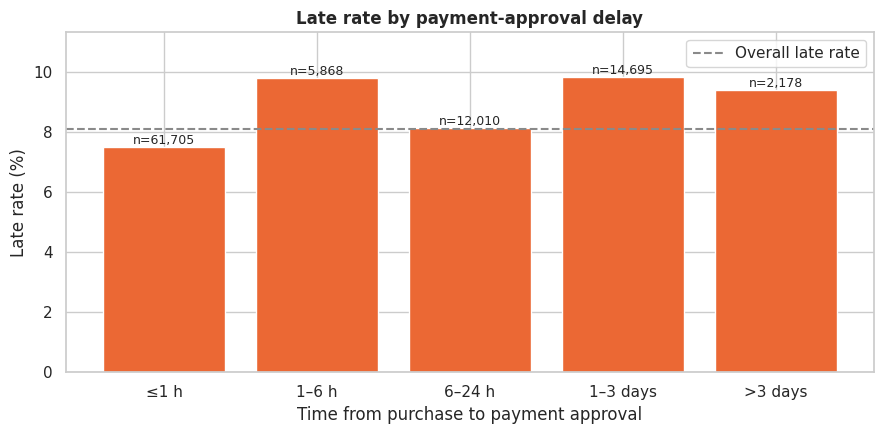

,orders,late_rate_%
approval_lag_bin,,
≤1 h,61705,7.49
1–6 h,5868,9.78
6–24 h,12010,8.13
1–3 days,14695,9.84
>3 days,2178,9.41


In [34]:
lag_bins = [-0.001, 1, 6, 24, 72, np.inf]
lag_labels = ["≤1 h", "1–6 h", "6–24 h", "1–3 days", ">3 days"]
target_df["approval_lag_bin"] = pd.cut(target_df["eda_approval_lag_hours"], bins=lag_bins, labels=lag_labels)
late_by_lag = target_df.groupby("approval_lag_bin", observed=True)["is_late_delivery"].agg(orders="count", late_rate="mean")
late_by_lag["late_rate_%"] = (late_by_lag["late_rate"] * 100).round(2)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(late_by_lag.index.astype(str), late_by_lag["late_rate_%"], color=COLOR_LATE)
ax.axhline(overall_rate, color=COLOR_NEUTRAL, linestyle="--", label="Overall late rate")
for i, (r, n) in enumerate(zip(late_by_lag["late_rate_%"], late_by_lag["orders"])):
    ax.text(i, r, f"n={n:,}", ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, late_by_lag["late_rate_%"].max() * 1.15)
ax.set_title("Late rate by payment-approval delay")
ax.set_xlabel("Time from purchase to payment approval")
ax.set_ylabel("Late rate (%)")
ax.legend()
plt.tight_layout()
plt.show()
late_by_lag[["orders", "late_rate_%"]]

**Interpretation:** Most orders are approved within an hour, but there is a long tail of multi-day approvals.
Orders approved **within 1 hour** have the lowest late rate. All slower-approval groups are **somewhat higher**, although the pattern is
not strictly increasing. The approval delay therefore carries some (modest) predictive signal. It is plausible: the promised date is fixed at purchase, so every hour spent waiting for approval eats into the buffer.

### ⚠️ Prediction-point ambiguity (must be confirmed by the team)
The project documentation is **not consistent** about when the prediction is made:

| Source | What it says |
|---|---|
| README, tagline | *"Predicting, **at order-placement time**, whether a newly placed order is at risk…"* |
| README, Problem statement | *"…using only information available **before dispatch**…"* |
| Assignment brief (IT3051) | Does not define a prediction point. It only requires leakage to be identified and prevented. |

These are **two different prediction points**:

| Prediction point | Is `order_approved_at` allowed? | Why |
|---|---|---|
| **A. Immediately after order placement** | ❌ No | Approval has not happened yet (it can take days). Using it would be future information. |
| **B. After payment approval, before dispatch** | ✅ Yes | Approval is already known, and dispatch/delivery are not. |

**Decision in this notebook:** *not* resolved silently. The engineered column `approval_lag_hours` is **kept in
`orders_clean.csv` but explicitly marked as CONDITIONAL** (see Section 17 and the report). It must be **dropped by Member D if
the team chooses point A**. It can be used if the team chooses point B. All other features in the output are valid under
**both** prediction points.

## 15. Optional: review scores (EDA sanity check only, never a feature)
Reviews are written **after** the customer receives (or fails to receive) the order. They are post-outcome information and
**must never be used as model features**. We only use them to check that our target makes business sense: late orders should
receive worse reviews.

If `olist_order_reviews_dataset.csv` is not in `data/raw/`, this section is skipped automatically.

In [35]:
if os.path.exists(REVIEWS_PATH):
    reviews = pd.read_csv(REVIEWS_PATH, usecols=["order_id", "review_score"])
    # An order can have more than one review → average per order (EDA only)
    review_per_order = reviews.groupby("order_id", as_index=False)["review_score"].mean()
    review_check = target_df[["order_id", "is_late_delivery"]].merge(review_per_order, on="order_id", how="left")

    print("Target orders with a review:", review_check["review_score"].notna().sum(), "of", len(review_check))
    print(review_check.groupby("is_late_delivery")["review_score"].agg(["count", "mean", "median"]).round(2))

    fig, ax = plt.subplots(figsize=(8, 4.5))
    share = (review_check.dropna(subset=["review_score"])
             .assign(score=lambda d: d["review_score"].round().astype(int))
             .groupby("is_late_delivery")["score"].value_counts(normalize=True)
             .mul(100).unstack(0).fillna(0))
    share.plot(kind="bar", color=[COLOR_ON_TIME, COLOR_LATE], ax=ax, rot=0)
    ax.set_title("Review score distribution: on-time vs late orders (EDA only)")
    ax.set_xlabel("Review score (1 = worst, 5 = best)")
    ax.set_ylabel("% of orders in class")
    ax.legend(["On time (0)", "Late (1)"])
    plt.tight_layout()
    plt.show()
    del reviews, review_per_order, review_check   # make sure nothing review-related reaches the output
else:
    print("Reviews file not found at", REVIEWS_PATH, "→ optional review sanity check skipped.")
    print("(Review information is post-outcome and is never used as a feature anyway.)")

Reviews file not found at ../data/raw/olist_order_reviews_dataset.csv → optional review sanity check skipped.
(Review information is post-outcome and is never used as a feature anyway.)


---
# PART 3: Leakage Analysis

## 16. Column roles: target construction vs EDA vs model input
We make a clear distinction between three uses of a column:
- **A. Used to construct the target.** Needed once to create the label, then removed.
- **B. Used for EDA only.** Helps us understand the problem, but describes the outcome or post-prediction events.
- **C. Passed to the model.** Must be known at the prediction point.

| Column | A. Target | B. EDA | C. Model input? | Reason |
|---|---|---|---|---|
| `order_id` | | | ❌ (merge key only) | Identifier: random hash with no predictive meaning. Kept for merging. |
| `customer_id` | | | ❌ (merge key only) | Identifier: kept so Member D can join Member B's customer table. |
| `order_status` | ✅ (population filter) | ✅ | ❌ | Final status is only known at the end. After filtering, it is constant (`delivered`) and carries no information. |
| `order_purchase_timestamp` | | ✅ | ❌ raw / ✅ via derived features | Known at placement. Kept raw **only** for the chronological split and for Member C's shipping-deadline duration. |
| `order_approved_at` | | ✅ | ⚠️ **conditional** | Valid only if prediction point = after approval (Section 14). |
| `order_delivered_carrier_date` | | ✅ | ❌ **leakage** | Known only after dispatch, which is after both candidate prediction points. |
| `order_delivered_customer_date` | ✅ | ✅ | ❌ **leakage** | This *is* the outcome. |
| `order_estimated_delivery_date` | ✅ | ✅ | ✅ via `estimated_delivery_days` | Promised at checkout, so known at placement. |
| `eda_actual_delivery_days` | | ✅ | ❌ **leakage** | Computed from the actual delivery date. |
| `eda_delay_days` | | ✅ | ❌ **leakage** | `delay_days > 0` **is** the target. |
| `review_score` (other table) | | ✅ (optional) | ❌ **leakage** | Written after delivery. |
| `is_late_delivery` | (the target) | ✅ | Target `y`, never `X` | Must be separated from the features by Member D. |

We also run a quick numeric illustration of *why* delay-based columns are forbidden: they separate the classes perfectly,
which no legitimate feature would do.

In [36]:
# If delay_days were used as a feature, a single rule "delay_days > 0" would reproduce the target exactly:
rule = (target_df["eda_delay_days"] > 0).astype(int)
print("Agreement between 'eda_delay_days > 0' and the target:",
      f"{(rule == target_df['is_late_delivery']).mean() * 100:.2f}%")
print("→ 100% agreement proves delay_days is the target in disguise and must never be a feature.")

Agreement between 'eda_delay_days > 0' and the target: 100.00%
→ 100% agreement proves delay_days is the target in disguise and must never be a feature.


---
# PART 4: Preprocessing & Feature Engineering (Stage 4)

## 17. Feature engineering: each feature justified
We only create features that are (1) known at the prediction point and (2) supported by the EDA above.

| Feature | Formula | Valid at placement? | Evidence / reason |
|---|---|---|---|
| `purchase_month` | month of purchase (1–12) | ✅ | Late rate varies strongly by month (Section 13), e.g. peak-season congestion |
| `purchase_dayofweek` | 0 = Mon … 6 = Sun | ✅ | Small differences (Monday orders highest, weekend orders lowest; Section 13). Cheap to include; feature selection can drop it. |
| `purchase_hour` | 0–23 | ✅ | Small differences. Included for completeness; feature selection can drop it. |
| `estimated_delivery_days` | (estimated date − purchase) in days | ✅ (promised at checkout) | Clear relationship with lateness (Section 12). It measures the size of the buffer. |
| `approval_lag_hours` | (approved − purchase) in hours | ⚠️ **only for point B** | Some signal (Section 14). **Conditional**: team must confirm. |

**Candidate features considered and rejected:**
- `purchase_year`: rejected. With a chronological split, the deployed system will always see future years the model has
  never seen. Year only encodes the specific history of 2016–2018, not a repeatable pattern (Section 13).
- `purchase_is_weekend`: rejected as redundant. It is fully determined by `purchase_dayofweek`.
- `actual_delivery_days`, `delay_days`, `carrier_pickup_days`: rejected as **leakage** (Section 16).
- Raw `order_estimated_delivery_date` / `order_approved_at`: replaced by the duration features, which are easier for models to use.
- `order_status`: constant after filtering and post-outcome.

In [37]:
features = target_df[["order_id", "customer_id", "order_purchase_timestamp", "is_late_delivery"]].copy()

features["purchase_month"] = features["order_purchase_timestamp"].dt.month
features["purchase_dayofweek"] = features["order_purchase_timestamp"].dt.dayofweek
features["purchase_hour"] = features["order_purchase_timestamp"].dt.hour

features["estimated_delivery_days"] = (
    (target_df["order_estimated_delivery_date"] - target_df["order_purchase_timestamp"]).dt.total_seconds()
    / SECONDS_PER_DAY
).round(2)

# CONDITIONAL feature: only valid if the team's prediction point is "after payment approval"
features["approval_lag_hours"] = (
    (target_df["order_approved_at"] - target_df["order_purchase_timestamp"]).dt.total_seconds() / 3600
).round(2)

features.head()

,order_id,customer_id,order_purchase_timestamp,is_late_delivery,purchase_month,purchase_dayofweek,purchase_hour,estimated_delivery_days,approval_lag_hours
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,0,10,0,10,15.54,0.18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,0,7,1,20,19.14,30.71
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,0,8,2,8,26.64,0.28
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18 19:28:06,0,11,5,19,26.19,0.30
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13 21:18:39,0,2,1,21,12.11,1.03


In [38]:
# Relationship of each numeric feature with the target (point-biserial = Pearson with a 0/1 variable).
# Only a rough linear indicator: month/day/hour are cyclical codes, so a low value does not mean "useless".
feature_cols = ["purchase_month", "purchase_dayofweek", "purchase_hour", "estimated_delivery_days", "approval_lag_hours"]
features[feature_cols + ["is_late_delivery"]].corr()["is_late_delivery"].drop("is_late_delivery").round(3).to_frame("corr_with_target")

,corr_with_target
purchase_month,-0.025
purchase_dayofweek,-0.015
purchase_hour,0.009
estimated_delivery_days,-0.060
approval_lag_hours,0.029


**Interpretation:** All linear correlations with the target are **weak**. This is expected: the orders table alone
describes *when* an order was placed, not *who* sells it, *what* it is or *where* it goes. The predictive power of the project will come
mainly from combining these features with the seller/customer/geo (B), product/item (C) and payment (D) features.
`estimated_delivery_days` has a negative correlation, which is consistent with Section 12 (longer promise → less often late).

## 18. Outliers and unusual observations
We use the IQR rule (values beyond Q1 − 1.5·IQR or Q3 + 1.5·IQR) to **count** unusual values in the numeric features.
The same approach is used in notebooks 03 and 04.

In [39]:
def iqr_bounds(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

outlier_summary = []
for col in ["estimated_delivery_days", "approval_lag_hours"]:
    s = features[col].dropna()
    low, high = iqr_bounds(s)
    outlier_summary.append({
        "feature": col, "min": s.min(), "median": s.median(), "max": s.max(),
        "iqr_lower": round(low, 2), "iqr_upper": round(high, 2),
        "n_outliers": int(((s < low) | (s > high)).sum()),
        "pct_outliers": round(((s < low) | (s > high)).mean() * 100, 2),
    })
pd.DataFrame(outlier_summary)

,feature,min,median,max,iqr_lower,iqr_upper,n_outliers,pct_outliers
0,estimated_delivery_days,2.01,23.23,155.14,3.21,43.53,2417,2.51
1,approval_lag_hours,0.00,0.34,741.44,-21.23,35.97,8930,9.26


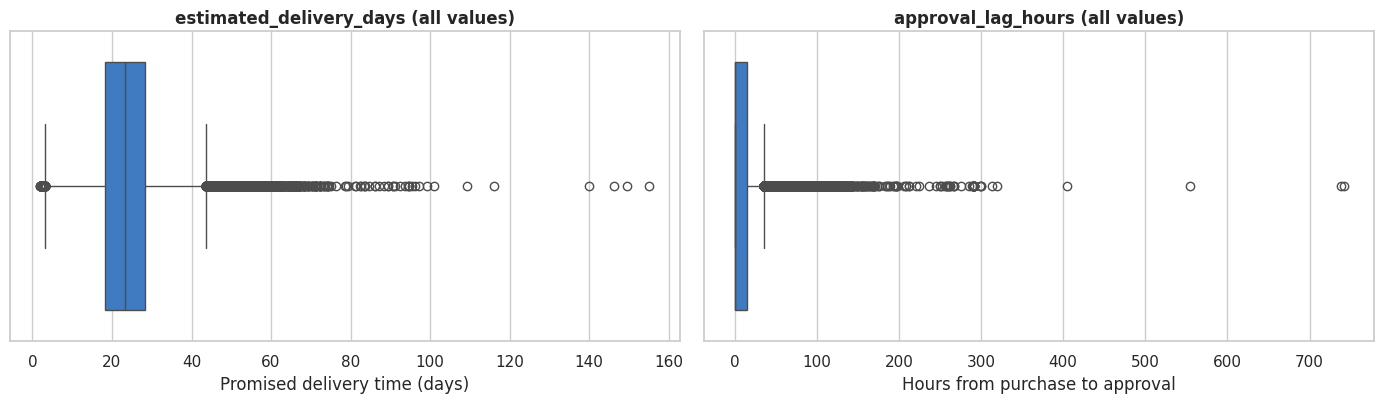

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
sns.boxplot(x=features["estimated_delivery_days"], color=COLOR_ON_TIME, ax=axes[0])
axes[0].set_title("estimated_delivery_days (all values)")
axes[0].set_xlabel("Promised delivery time (days)")
sns.boxplot(x=features["approval_lag_hours"], color=COLOR_ON_TIME, ax=axes[1])
axes[1].set_title("approval_lag_hours (all values)")
axes[1].set_xlabel("Hours from purchase to approval")
plt.tight_layout()
plt.show()

In [41]:
# Do the extreme promised times behave differently? Compare late rate for IQR outliers vs the rest.
low, high = iqr_bounds(features["estimated_delivery_days"])
is_out = features["estimated_delivery_days"] > high
print(f"Upper IQR bound for estimated_delivery_days: {high:.2f} days")
print(features.groupby(is_out)["is_late_delivery"].agg(orders="count", late_rate="mean")
      .rename(index={False: "normal range", True: "above upper bound"}).round(4))
print("\nLongest promised times (days):", features["estimated_delivery_days"].nlargest(5).tolist())

Upper IQR bound for estimated_delivery_days: 43.53 days
                         orders  late_rate
estimated_delivery_days                   
normal range              94290     0.0826
above upper bound          2180     0.0183

Longest promised times (days): [155.14, 149.59, 146.25, 140.06, 116.1]


**Interpretation:**
- Both features are **right-skewed** with a long upper tail. Some orders have very long promises (months), and some approvals take
  many days. These values look like **plausible business situations**. Possible causes are remote destinations or slow-clearing payment methods,
  although this cannot be confirmed from the orders table alone. They are not recording errors: none are negative, and none contradict the timeline (Section 6).
- Orders with outlying (very long) promised times have a **much lower** late rate than the rest (printed above). The extreme values
  therefore carry real information and are not noise.

**Decision: keep outliers, no capping or removal.** Removing them would delete genuine orders and real signal, and it
would also be impossible in production (we cannot refuse to score a real order because its promise is long). If the team
uses a scale-sensitive model (logistic regression, KNN, SVM), a `log1p` transform or a robust scaler can be applied
**inside the modelling pipeline, fitted on the training data only** (Member D / Stage 6).

## 19. Remaining preprocessing decisions
| Aspect | Finding | Decision and reason |
|---|---|---|
| **Missing values** | Only `approval_lag_hours` has missing values (delivered orders without an approval timestamp, Section 5) | **Left as NaN on purpose.** (1) The column is conditional and may be dropped entirely. (2) If it is kept, imputing (e.g. with the median) must be **fitted on the training split only** to avoid leakage. That happens after Member D's split, not here. |
| **Duplicates** | None (Section 2) | Nothing removed. Uniqueness is re-checked on the output. |
| **Invalid records** | Status/date contradictions and non-delivered orders | Handled by the target-population filter (Section 8). Carrier-date inconsistencies are kept because that column is not used (Section 6). |
| **Data types** | Dates were text | Converted to datetime. Engineered features are integers/floats. The timestamp is saved in ISO format. |
| **Encoding** | `purchase_month/dayofweek/hour` are small integer codes | **Not one-hot encoded here.** Tree models can use them directly. Whether to one-hot or use cyclical (sin/cos) encoding depends on the chosen algorithm, and should be decided in the final pipeline so that all members' features are encoded consistently. |
| **Scaling** | Features have different ranges | **Not scaled here.** Scaling must be fitted on the training set only (after the split), otherwise test-set statistics leak into training. This is already planned in notebook 05, step 6. |
| **Class imbalance** | Late is the minority class (Section 10) | Not resampled here. Resampling belongs after the split, on training data only. |
| **Train/test split** | Strong drift in late rate over time (Section 13) | Recommend a **chronological split** on `order_purchase_timestamp`, which is kept in the output for this purpose. The split itself is Member D's responsibility. |

---
# PART 5: Final Output

## 20. Build `orders_clean` and run final quality checks
Final columns and their role:

| Column | Role |
|---|---|
| `order_id` | Merge key (unique) |
| `customer_id` | Merge key → customers table (Member B) |
| `order_purchase_timestamp` | **Not a direct model input.** Used for the chronological split (D) and for the shipping-deadline duration with Member C's `shipping_limit_date` |
| `purchase_month`, `purchase_dayofweek`, `purchase_hour` | Model features (valid at placement) |
| `estimated_delivery_days` | Model feature (valid at placement) |
| `approval_lag_hours` | ⚠️ **Conditional** model feature (only if the prediction point is after approval) |
| `is_late_delivery` | **Target** (`y`) |

In [42]:
FINAL_COLUMNS = [
    "order_id",
    "customer_id",
    "order_purchase_timestamp",
    "purchase_month",
    "purchase_dayofweek",
    "purchase_hour",
    "estimated_delivery_days",
    "approval_lag_hours",
    "is_late_delivery",
]
orders_clean = features[FINAL_COLUMNS].copy().reset_index(drop=True)

print("Rows   :", orders_clean.shape[0])
print("Columns:", orders_clean.shape[1])
orders_clean.dtypes

Rows   : 96470
Columns: 9


order_id                               str
customer_id                            str
order_purchase_timestamp    datetime64[us]
purchase_month                       int32
purchase_dayofweek                   int32
purchase_hour                        int32
estimated_delivery_days            float64
approval_lag_hours                 float64
is_late_delivery                     int64
dtype: object

In [43]:
# ---- Quality checks ---------------------------------------------------------
print("1. Row count equals target population:", len(orders_clean) == len(target_df))
print("2. Duplicate order_id:", orders_clean["order_id"].duplicated().sum())
print("3. Duplicate customer_id:", orders_clean["customer_id"].duplicated().sum())
print("4. Target values:", orders_clean["is_late_delivery"].value_counts().sort_index().to_dict())
print("5. Missing target values:", orders_clean["is_late_delivery"].isna().sum())
print("\n6. Missing values per column:")
print(orders_clean.isna().sum().to_string())

1. Row count equals target population: True
2. Duplicate order_id: 0
3. Duplicate customer_id: 0
4. Target values: {0: 88644, 1: 7826}
5. Missing target values: 0

6. Missing values per column:
order_id                     0
customer_id                  0
order_purchase_timestamp     0
purchase_month               0
purchase_dayofweek           0
purchase_hour                0
estimated_delivery_days      0
approval_lag_hours          14
is_late_delivery             0


In [44]:
# ---- Range / validity checks --------------------------------------------------
print("purchase_month in 1..12     :", orders_clean["purchase_month"].between(1, 12).all())
print("purchase_dayofweek in 0..6  :", orders_clean["purchase_dayofweek"].between(0, 6).all())
print("purchase_hour in 0..23      :", orders_clean["purchase_hour"].between(0, 23).all())
print("estimated_delivery_days > 0 :", (orders_clean["estimated_delivery_days"] > 0).all())
print("approval_lag_hours >= 0     :", (orders_clean["approval_lag_hours"].dropna() >= 0).all())
print("Purchase timestamp range    :", orders_clean["order_purchase_timestamp"].min(), "→",
      orders_clean["order_purchase_timestamp"].max())
orders_clean.describe().round(2).T

purchase_month in 1..12     : True
purchase_dayofweek in 0..6  : True
purchase_hour in 0..23      : True
estimated_delivery_days > 0 : True
approval_lag_hours >= 0     : True
Purchase timestamp range    : 2016-09-15 12:16:38 → 2018-08-29 15:00:37


,count,mean,min,25%,50%,75%,max,std
order_purchase_timestamp,96470,2018-01-01 23:17:43.624411,2016-09-15 12:16:38,2017-09-14 08:56:46.500000,2018-01-20 19:34:43.500000,2018-05-05 18:29:50.250000,2018-08-29 15:00:37,NaN
purchase_month,96470.0,6.03,1.0,3.0,6.0,8.0,12.0,3.23
purchase_dayofweek,96470.0,2.76,0.0,1.0,3.0,4.0,6.0,1.97
purchase_hour,96470.0,14.77,0.0,11.0,15.0,19.0,23.0,5.33
estimated_delivery_days,96470.0,23.74,2.01,18.33,23.23,28.41,155.14,8.76
approval_lag_hours,96456.0,10.28,0.0,0.22,0.34,14.52,741.44,20.54
is_late_delivery,96470.0,0.08,0.0,0.0,0.0,0.0,1.0,0.27


In [45]:
# ---- Leakage check: none of these columns may appear in the output -------------
LEAKAGE_COLUMNS = [
    "order_status", "order_approved_at", "order_delivered_carrier_date",
    "order_delivered_customer_date", "order_estimated_delivery_date",
    "eda_actual_delivery_days", "eda_delay_days", "eda_estimated_delivery_days",
    "delay_days", "delivery_days", "review_score",
]
found = [c for c in LEAKAGE_COLUMNS if c in orders_clean.columns]
print("Leakage / raw outcome columns in output:", found if found else "none ✓")
print("Any EDA helper column in output        :", any(c.startswith("eda_") for c in orders_clean.columns))

# Hard stops: the notebook fails loudly if any of these conditions are violated
assert orders_clean["order_id"].is_unique
assert orders_clean["is_late_delivery"].isin([0, 1]).all()
assert orders_clean["is_late_delivery"].notna().all()
assert not found
assert (orders_clean["estimated_delivery_days"] > 0).all()
print("\nAll assertions passed ✓")

Leakage / raw outcome columns in output: none ✓
Any EDA helper column in output        : False

All assertions passed ✓


In [46]:
MODEL_FEATURES_SAFE = ["purchase_month", "purchase_dayofweek", "purchase_hour", "estimated_delivery_days"]
MODEL_FEATURES_CONDITIONAL = ["approval_lag_hours"]
NON_FEATURE_COLUMNS = {"order_id": "merge key", "customer_id": "merge key",
                       "order_purchase_timestamp": "split key / duration helper", "is_late_delivery": "TARGET"}
print("Model features valid at order placement :", MODEL_FEATURES_SAFE)
print("Conditional (only if predicting after approval):", MODEL_FEATURES_CONDITIONAL)
print("Not model inputs:", NON_FEATURE_COLUMNS)

Model features valid at order placement : ['purchase_month', 'purchase_dayofweek', 'purchase_hour', 'estimated_delivery_days']
Conditional (only if predicting after approval): ['approval_lag_hours']
Not model inputs: {'order_id': 'merge key', 'customer_id': 'merge key', 'order_purchase_timestamp': 'split key / duration helper', 'is_late_delivery': 'TARGET'}


## 21. Save `orders_clean.csv`

In [47]:
os.makedirs("../data/processed", exist_ok=True)
orders_clean.to_csv(OUT_PATH, index=False)

# Reload and verify that the saved file matches what we built
saved = pd.read_csv(OUT_PATH, parse_dates=["order_purchase_timestamp"])
print("Saved to:", OUT_PATH)
print("Saved shape:", saved.shape)
print("Same columns:", saved.columns.tolist() == FINAL_COLUMNS)
print("Same late count:", saved["is_late_delivery"].sum() == orders_clean["is_late_delivery"].sum())
saved.head()

Saved to: ../data/processed/orders_clean.csv
Saved shape: (96470, 9)
Same columns: True
Same late count: True


,order_id,customer_id,order_purchase_timestamp,purchase_month,purchase_dayofweek,purchase_hour,estimated_delivery_days,approval_lag_hours,is_late_delivery
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,10,0,10,15.54,0.18,0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,7,1,20,19.14,30.71,0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,8,2,8,26.64,0.28,0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18 19:28:06,11,5,19,26.19,0.30,0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13 21:18:39,2,1,21,12.11,1.03,0


## 22. Summary

**What this notebook produced:** `data/processed/orders_clean.csv`, with one row per delivered order. It contains merge keys,
the split timestamp, 4 always-valid features, 1 conditional feature and the target. All numbers quoted below are printed by the
cells above.

**Key findings:**
1. The orders table is clean at the key level: no duplicate rows, `order_id` and `customer_id` unique, all dates parseable.
2. Missing dates are **structural** (they follow the order status). They are handled by choosing the target population, not by imputation.
3. Target population = `delivered` orders with a known delivery date. Late orders are a **minority class** (Section 10) → use
   imbalance-aware metrics and handling after the split.
4. Olist's promises are conservative (most orders arrive early). Lateness is about exceeding the buffer.
5. Longer promised delivery time → lower late rate (non-linear).
6. The late rate **drifts strongly over time** (spikes in Nov 2017 and Feb–Mar 2018) → chronological split.
7. The carrier-date column has timeline inconsistencies, but it is excluded as leakage anyway.

**Decisions the team must confirm:**
1. **Prediction point:** at order placement (drop `approval_lag_hours`) **or** after payment approval (keep it). The README says both.
2. **Late definition at the day boundary:** keep the strict timestamp rule, or treat delivery on the promised calendar day as on time
   (changes a noticeable share of late labels, Section 10.1).
3. **Encoding/scaling** of the time features and the **imputation** of `approval_lag_hours` belong in the final pipeline, fitted on training data only.
4. Whether to include the sparse **2016** orders in training (few orders, gaps in months).